# CNN Activity - Week 7c
**Project Information:** CNN-based Image Classification

**Prepared by:** Mosqueda, Christine Reisa & Viernes, Jhon Lloyd

# TASK 1: Problem framing & data plan

## Task Statement
This project aims to train an image classification model using Convolutional Neural Network algorithm on the CIFAR-10 dataset.


- **Dataset:** CIFAR-10
- **Image Size:** Each image is 32x32 in pixels and colored in RGB (Red, Green, Blue) values
- **Classes:** 10
- **Source & License:** CIFAR-10 dataset was created by Alex Krizhevsky, Vinod Nair, Geoffrey Hinton under public domain license.
- **Citation:** CIFAR-10 and CIFAR-100 datasets. (2025). Toronto.edu. https://www.cs.toronto.edu/~kriz/cifar.html


## Class Distribution
- **Total No. of Instances:** 60,000 images
- **Distribution:** 10 classes x 6000 images per class
- **Classes:** index from 0 - 9 (class size = 10)
  - airplane
  - automobile
  - bird
  - cat
  - deer
  - dog
  - frog
  - horse
  - ship
  - truck

- **Train Set and Test Set Distribution:**
  - 5,000 train sets for each class
  - 1,000 test sets for each class
  - **Total:** 50,000 train sets, 10,000 test sets


## CIFAR-10 Class Names & Counts (Markdown Table)

| Class Name | Train Count | Validation Count | Test Count | Total Count |
| ---------- | ----------: | ---------------: | ---------: | ----------: |
| airplane   |       4,500 |              500 |      1,000 |       6,000 |
| automobile |       4,500 |              500 |      1,000 |       6,000 |
| bird       |       4,500 |              500 |      1,000 |       6,000 |
| cat        |       4,500 |              500 |      1,000 |       6,000 |
| deer       |       4,500 |              500 |      1,000 |       6,000 |
| dog        |       4,500 |              500 |      1,000 |       6,000 |
| frog       |       4,500 |              500 |      1,000 |       6,000 |
| horse      |       4,500 |              500 |      1,000 |       6,000 |
| ship       |       4,500 |              500 |      1,000 |       6,000 |
| truck      |       4,500 |              500 |      1,000 |       6,000 |

**Class imbalance:** CIFAR-10 is balanced by design (6,000 images per class). Each class remains evenly distributed across training, validation, and test splits.



## Split Strategy
- **Train Set:** 45,000 images (4,500 per class)
- **Validation:** 5,000 images (500 per class), carved out from original test set using a fixed random seed -> `random_state=42`
- **Test Set:** 10,000 images (1,000 per class) from original test set, kept untouched until final evaluation.


## Preprocessing Strategy

1. Resize images to 96x96 using bilinear interpolation.
2. Convert to float and scale pixel values to [0,1]
3. Channel normalization (per channel mean/std):
  - Mean = [0.4914, 0.4822, 0.4465]
  - Std = [0.2023, 0.1994, 0.2010] , apply (x - mean)/std after scaling to [0,1]
4. Class label encoding: integer class IDs 0–9

## Data augmentation for train set

- **Random flip:** horizontal
- **Random crop:** 96,96
- **Random rotation:** 0.04
- **Random brightness:** factor=0.1
- **Random contrast:** factor=0.1
- **Random zoom:** 0.05

## Metrics

- **Primary Metric:** Top-1 Accuracy. Percentage of test images where the predicted class exactly matches the true label.
- **Additional Analysis:** Confusion matrix. Visualize per-class performance and identify which class are often confused.

## EXPLORATORY DATA ANALYSIS

Here, we are performing EDA on full test and train sets (full dataset not yet preprocessed). We will be exploring the following aspects:

- Shapes of each sets (train and test) before flattening y_train and y_test sets
- Display some images with its class
- Class distribution
- Verify pixel scaling needs
- Check basic statistics
- Examine one class deeply -> `cat` class in class 3
- Check image shapes and sizes
- Mean & std per channel


In [61]:
# import necessary libraries
import tensorflow as tf
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras import layers, models, Sequential, optimizers
from sklearn.model_selection import train_test_split

# prepare import of cifar-10 dataset from keras
from tensorflow.keras.datasets import cifar10

In [62]:
# load cifar-10 data
(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()

# print shapes of each training (full) and test sets
print(f"Shapes of each set before flattening:\n\nX train: {x_train_full.shape}\nY train: {y_train_full.shape}\nX test: {x_test.shape}\nY test: {y_test.shape}\n")


Shapes of each set before flattening:

X train: (50000, 32, 32, 3)
Y train: (50000, 1)
X test: (10000, 32, 32, 3)
Y test: (10000, 1)



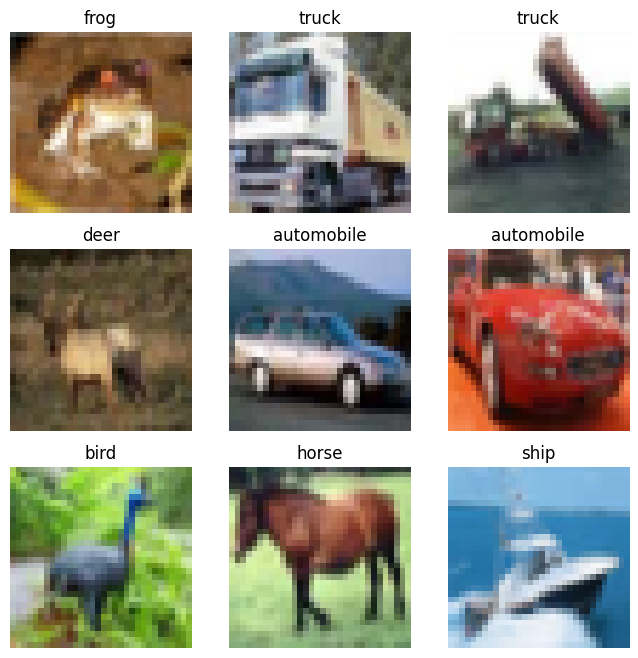

In [63]:
# class names definition
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# then, display some images from the dataset for verification
plt.figure(figsize=(8, 8))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(x_train_full[i])
    plt.title(class_names[y_train_full[i][0]])
    plt.axis('off')
plt.show()

In [64]:
# Check class distribution

unique, counts = np.unique(y_train_full, return_counts=True)
class_distrib_df = pd.DataFrame({"Class": [class_names[i] for i in unique], "Count": counts})
print(class_distrib_df.to_markdown())


|    | Class      |   Count |
|---:|:-----------|--------:|
|  0 | airplane   |    5000 |
|  1 | automobile |    5000 |
|  2 | bird       |    5000 |
|  3 | cat        |    5000 |
|  4 | deer       |    5000 |
|  5 | dog        |    5000 |
|  6 | frog       |    5000 |
|  7 | horse      |    5000 |
|  8 | ship       |    5000 |
|  9 | truck      |    5000 |


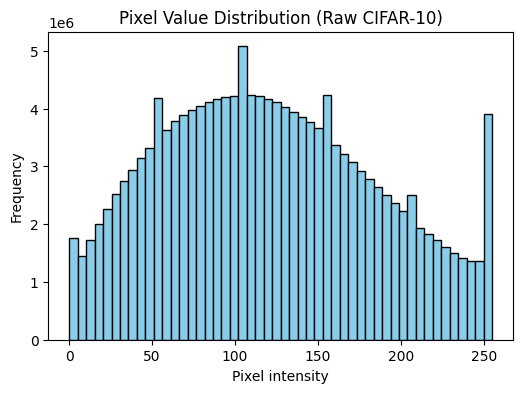

In [65]:
# Verify pixel scaling needs
plt.figure(figsize=(6,4))
plt.hist(x_train_full.flatten(), bins=50, color='skyblue', edgecolor='black')
plt.title("Pixel Value Distribution (Raw CIFAR-10)")
plt.xlabel("Pixel intensity")
plt.ylabel("Frequency")
plt.show()

In [66]:
# Check basic statistics
print("Basic statistics of pixel values:")
print("Min:", x_train_full.min())
print("Max:", x_train_full.max())
print("Mean:", x_train_full.mean())
print("Std:", x_train_full.std())

Basic statistics of pixel values:
Min: 0
Max: 255
Mean: 120.70756512369792
Std: 64.15007589112122


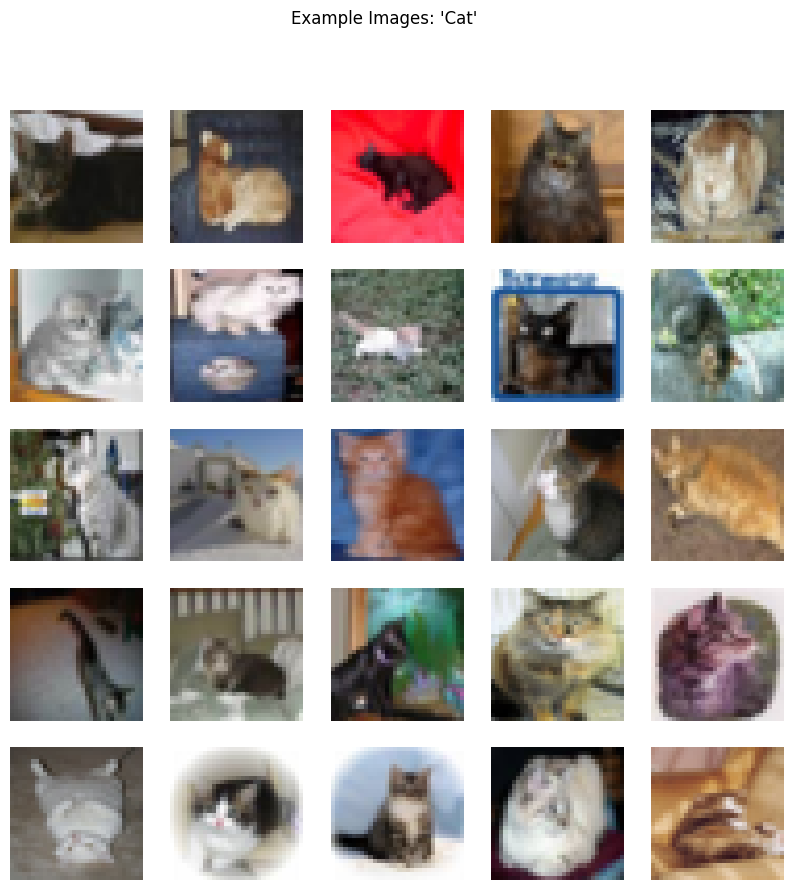

In [67]:
# Examine one class -> `cat` in class 3 deeply

cat_indices = np.where(y_train_full.flatten() == 3)[0]  # class 3 = cat
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(x_train_full[cat_indices[i]])
    plt.axis("off")
plt.suptitle("Example Images: 'Cat'")
plt.show()

In [68]:
# Check image shapes and channels

print("Image shape:", x_train_full[0].shape)
print("Data type:", x_train_full.dtype)

Image shape: (32, 32, 3)
Data type: uint8


In [69]:
# Check mean and std per channel

print("Mean:", np.mean(x_train_full / 255.0, axis=(0,1,2)))
print("Std:", np.std(x_train_full / 255.0, axis=(0,1,2)))

Mean: [0.49139968 0.48215841 0.44653091]
Std: [0.24703223 0.24348513 0.26158784]


## PREPROCESSING

Here, we performed preprocessing techniques before training CNN models.

In [70]:
# Flatten labels
y_train_full = y_train_full.flatten()
y_test = y_test.flatten()

# print shapes of each training (full) and test sets
print(f"Shapes of each set after flattening:\n\nX train: {x_train_full.shape}\nY train: {y_train_full.shape}\nX test: {x_test.shape}\nY test: {y_test.shape}\n")

Shapes of each set after flattening:

X train: (50000, 32, 32, 3)
Y train: (50000,)
X test: (10000, 32, 32, 3)
Y test: (10000,)



In [71]:
# parameters constants definition
IMG_SIZE = 96
BATCH_SIZE = 64

mean = tf.constant([0.4914, 0.4822, 0.4465])
std = tf.constant([0.2023, 0.1994, 0.2010])

In [72]:
# PERFORMING SPLITTING STRATEGY
# Here, we will carve out total of 5000 sets from full training set as our validation set

x_train, x_val, y_train, y_val = train_test_split(
    x_train_full, y_train_full, test_size=5000, random_state=42, stratify=y_train_full
)

print("Train:", x_train.shape)
print("Validation:", x_val.shape)
print("Test:", x_test.shape)

Train: (45000, 32, 32, 3)
Validation: (5000, 32, 32, 3)
Test: (10000, 32, 32, 3)


In [73]:
# DEFINING HELPER FUNCTIONS FOR PREPROCESSING
# here, we created preprocessing technique helper functions which involved scaling images to 96x96

# helper function for resizing to 96 height x 96 width and rescaling to [0,1]
def resize_and_rescale(image, label):
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    # image = tf.image.convert_image_dtype(image, tf.float32)  # scales to [0,1], ommitted for now
    return image, label

# helper function for normalizing images to default 255 scale
def normalize(image, label):
    image = image / 255.0
    return image, label

In [74]:
# DATA AUGMENTATION

data_augmentation = Sequential([
    layers.RandomFlip("horizontal", seed=42),
    layers.RandomCrop(96, 96),
    layers.RandomRotation(0.05),
    layers.RandomBrightness(factor=0.1),
    layers.RandomContrast(factor=0.1),
    layers.RandomZoom(0.05),
])

In [75]:
# CREATE TENSORFLOW DATASET
train_ds = (
    tf.data.Dataset.from_tensor_slices((x_train, y_train))
    .shuffle(10000)
    .map(resize_and_rescale)  # resize + scale [0,1]
    .map(lambda x, y: (data_augmentation(x, training=True), y))  # augment after scaling
    .map(normalize)  # normalize with mean/std (for [0,1] images)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((x_val, y_val))
    .map(resize_and_rescale)
    .map(normalize)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = (
    tf.data.Dataset.from_tensor_slices((x_test, y_test))
    .map(resize_and_rescale)
    .map(normalize)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

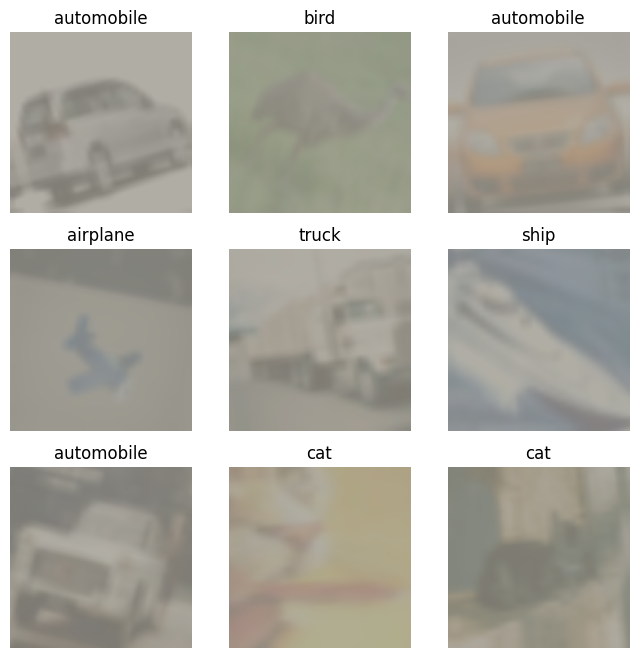

In [76]:
# VERIFY PREPROCESSING AND AUGMENTATION

for images, labels in train_ds.take(1):
    plt.figure(figsize=(8,8))
    for i in range(9):
        ax = plt.subplot(3,3,i + 1)
        img = images[i].numpy()
        # unnormalize for display
        img = (img * std + mean)
        img = tf.clip_by_value(img, 0, 1)
        plt.imshow(img)
        plt.title(class_names[int(labels[i])])
        plt.axis("off")
    plt.show()


# USER-DEFINED BASELINE CNN

In this section, we trained our user-defined baseline CNN model which should function as the _weak_ model in this activity.

In [77]:
# building the baseline model

baseline_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    # block 1
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D((2,2)),

    # block 2
    tf.keras.layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D((2,2)),

    # block 3
    tf.keras.layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D((2,2)),

    # dense layers -> softmax
    tf.keras.layers.Flatten(),  # ensures output adapts to any feature map size
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

In [78]:
# compiling and training the baseline model
baseline_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# early stopping callback, to prevent overfitting
early_stop = EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True
)

history_baseline = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop],
    batch_size=BATCH_SIZE
)

Epoch 1/20
296/704 ━━━━━━━━━━━━━━━━━━━━ 3:23 500ms/step - accuracy: 0.3064 - loss: 1.8928

KeyboardInterrupt: 

In [ ]:
# evaluate on test set
test_loss, test_acc = baseline_model.evaluate(test_ds)
print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

In [ ]:
# generate predictions

baseline_y_true = []
baseline_y_pred = []

for images, labels in test_ds:
    preds = baseline_model.predict(images)
    baseline_y_true.extend(labels.numpy())
    baseline_y_pred.extend(np.argmax(preds, axis=1))

# --- Compute confusion matrix ---
baseline_cm = confusion_matrix(baseline_y_true, baseline_y_pred)

# --- Plot confusion matrix ---
plt.figure(figsize=(10, 8))
sns.heatmap(
    baseline_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Confusion Matrix - CIFAR-10 Baseline CNN")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

In [ ]:
# classification report

print("\nClassification Report for Baseline Model:")
print(classification_report(baseline_y_true, baseline_y_pred, target_names=class_names))

# TASK 3: STRONGER CNN MODEL

In this section, we trained the _stronger_ CNN model that should outperform the weak model/baseline model defined previously.

In [ ]:
# building a stronger model with more layers, batch normalization, dropout, and global average pooling
stronger_model = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    # Block 1
    layers.Conv2D(32, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.Conv2D(32, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    # Block 2
    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.3),

    # Block 3
    layers.Conv2D(128, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.Conv2D(128, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.4),

    # Global Average Pooling instead of Flatten
    layers.GlobalAveragePooling2D(),

    # Dense Head
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

In [ ]:
# compile and train the stronger model
stronger_model.compile(
    optimizer=optimizers.Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop_strong = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history_strong = stronger_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop_strong],
    batch_size=BATCH_SIZE
)

In [ ]:
# evaluate on test set
test_loss, test_acc = stronger_model.evaluate(test_ds)
print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

In [ ]:
stronger_y_true = []
stronger_y_pred = []

for images, labels in test_ds:
    preds = stronger_model.predict(images)
    stronger_y_true.extend(labels.numpy())
    stronger_y_pred.extend(np.argmax(preds, axis=1))

# --- Compute confusion matrix ---
stronger_cm = confusion_matrix(stronger_y_true, stronger_y_pred)

# --- Plot confusion matrix ---
plt.figure(figsize=(10, 8))
sns.heatmap(
    stronger_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Confusion Matrix - CIFAR-10 Stronger CNN")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

In [ ]:
# classification report

print("\nClassification Report for Stronger Model:")
print(classification_report(stronger_y_true, stronger_y_pred, target_names=class_names))